# **Tutorial 2:** Modeling on Well-Log Data

Rock physics modeling on well log data is similar to modeling on scalar data. In this tutorial, before we jump to the modeling, we need to learn about two additional concepts:
1- Reading the LAS file
2- Displaying the logs

## Reading The LAS file
we use the `lasio` package to read the well logs from LAS file. Our example data is a LAS file from North-Sea. The file contains following well log:

['DEPT', 'VCL', 'PHIT', 'SW', 'VP', 'VS', 'RHOB']

Each of this well logs are stored as a `curve` in the las object that is read by `lasio`. Each `curve` has different attributes such as  `data`, `mnemonic`, `unit`, etc. 

In [7]:
import lasio
from rokpy.visualization import display_las

# Read Las-file
lasfile = r".\\wellA.las"
las = lasio.read(lasfile)

print(f'Available well logs in the LAS file:\n{las.keys()}')


# Users may also convert LAS to a DataFrame table which is more convinient 
welllogsdf = las.df().reset_index() #reset_index causes the Depth curve to be treated as a simple log rather than being treated as an index log.

depth = las.depth_m
# Extract required well logs from the file
vp_log = las.curvesdict['VP'].data
vs_log = las.curvesdict['VS'].data
rho_log = las.curvesdict['RHOB'].data
phit_log = las.curvesdict['PHIT'].data
vcly_log = las.curvesdict['VCL'].data
sw_log = las.curvesdict['SW'].data

# Some of attributes of a curve:
print(f'Number of samples:  {las.curvesdict['VP'].data.size}')
print(f'Log name:           {las.curvesdict['VP'].mnemonic}')
print(f'Log unit:           {las.curvesdict['VP'].unit}')


Available well logs in the LAS file:
['DEPT', 'VCL', 'PHIT', 'SW', 'VP', 'VS', 'RHOB']
Number of samples:  629
Log name:           VP
Log unit:           m/s


## Displaying the Well-logs
`rokpy` includes a simple module called `visualization` to display well logs. This module contains (but not limited to) two main classes of `Sheet` and `Track` that are subclasses of Matplotlib's `Figure` and `Axes`, respectively. 
`Sheet` is a figure that may contain several figures. According to Matplotlib documentation, it's recommended that subclasses of `Figure`, Like `Sheet` be instantiated throgh following command rather than `sheet = Sheet()`.
``` python
sheet = plt.figure(FigureClass=Sheet, figsize=(9, 12))
```
`Track`s are the axes the data are plotted on. Each tracks requires a `PropertyTemplate` that defines its data type, display range and unit. Available `PropertyTemplates` are stored in `rokpy.constants` module.
In addition to simple arrays of log data, users may also display `ComponentSet`s in a good-looking colored style on the tracks. we will display `MineralSet`s and `FluidSet`s by this method in the following cells.


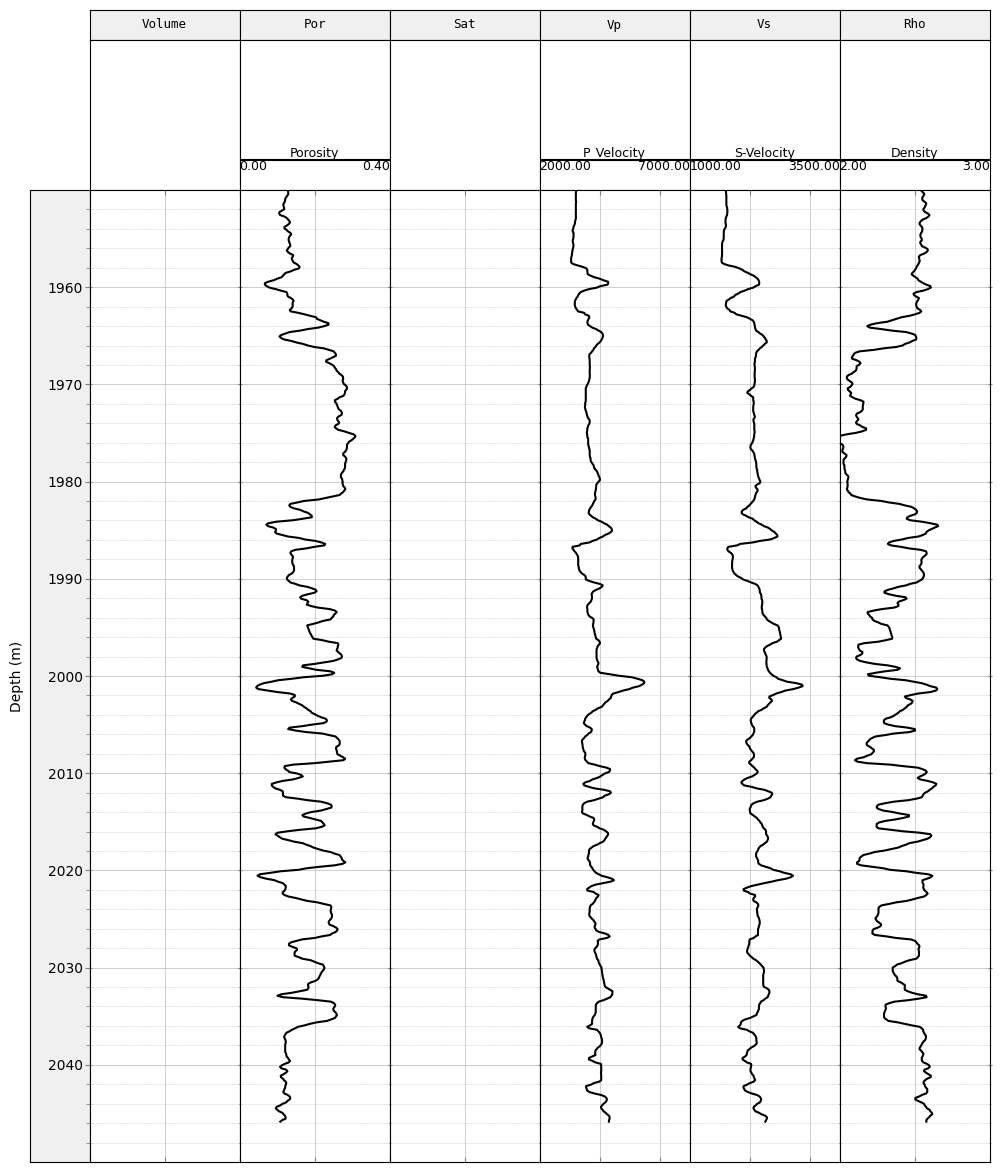

In [8]:
import matplotlib.pyplot as plt
from rokpy.visualization import Sheet
from rokpy.constants import PropertyTemplates

# Define PropertyTemplates
templates = PropertyTemplates()
# templates.PVelocity.plot_range=(1500., 3000.)
# templates.SVelocity.plot_range=(600., 1500.)
# templates.Density.plot_range=(1.45, 2.9)

# Define Log Sheet
sheet = plt.figure(FigureClass=Sheet, figsize=(9, 12))
sheet.set_depth_range(1950,2050)

# Add tracks to the sheet
vol_tr = sheet.add_track(templates.VolumeFraction)
por_tr = sheet.add_track(templates.Porosity)
sat_tr = sheet.add_track(templates.Saturation)
vp_tr = sheet.add_track(templates.PVelocity)
vs_tr = sheet.add_track(templates.SVelocity)
ro_tr = sheet.add_track(templates.Density)

# Disply each logs on the corresponding tracks
por_tr.plot(depth, phit_log, label='Porosity')
vp_tr.plot(depth, vp_log, label='P_Velocity')
vs_tr.plot(depth, vs_log, label='S-Velocity')
ro_tr.plot(depth, rho_log, label='Density')

## Modeling by `InclusionRock` Class
Now we can start rock modeling. As the litholog in this example is a shaly sandstone, we use Xu-White (1995) strategy to model the rock. During the modeling we have to optimize the minerals and fluids elastic properties as well as inclusion specifications. 

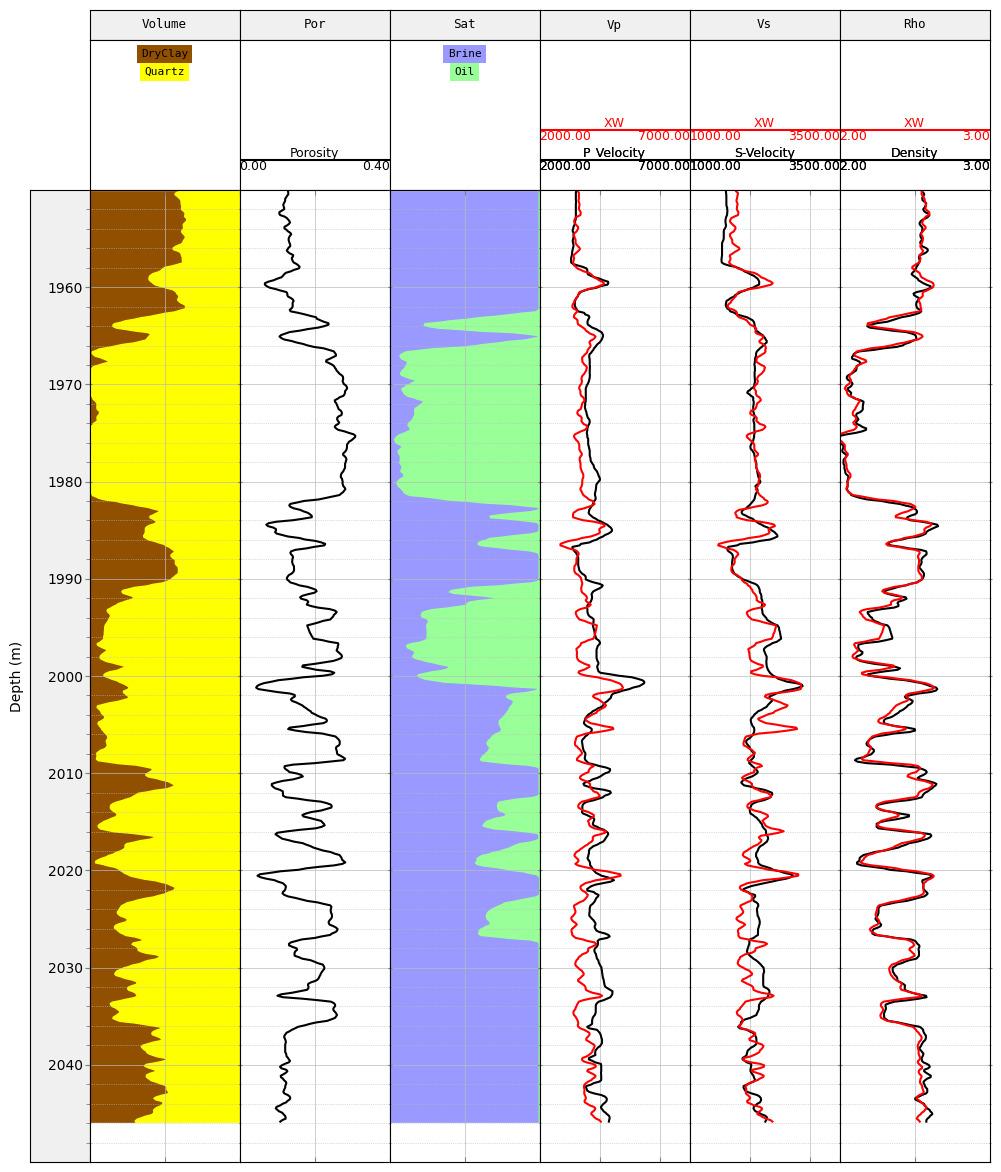

In [9]:
from rokpy.constants import PropertyTemplates, MineralsPropertyTable, FluidsPropertyTable
from rokpy.materials import Mineral, Fluid, MineralSet, FluidSet, InclusionRock
from rokpy.effective_medium import BoundMethods, InclusionMethods, Inclusion, ShapeName
import warnings
warnings.filterwarnings('ignore')

# Define, modify and display the mineralset
minerals = MineralsPropertyTable()
minerals.DryClay.set_properties(27, 7, 2.85)
minerals.Quartz.set_properties(45, 45, 2.65)
clay = Mineral(minerals.DryClay)
quartz = Mineral(minerals.Quartz)
mineralset = MineralSet({clay: vcly_log, quartz:1-vcly_log}, BoundMethods.MixingMethodName.VoigtReussHill)
vol_tr.plot_component_set(depth, mineralset)

# Define, modify and display the fluidset
fluid_props = FluidsPropertyTable()
fluid_props.Brine.set_properties(2.37, 0, 1.1)
fluid_props.Oil.set_properties(1.25, 0, 0.45)
brine = Fluid(fluid_props.Brine)
oil = Fluid(fluid_props.Oil)
fluidset = FluidSet({brine: sw_log, oil:1-sw_log})
sat_tr.plot_component_set(depth, fluidset)

clay_inclusion = Inclusion(ShapeName.SPHEROID, 0.07)
quartz_inclusion = Inclusion(ShapeName.SPHEROID, 0.11)
phit = phit_log


# Define Rock
rock = InclusionRock( mineralset, fluidset, phit, InclusionMethods.InclusionMethodName.DEM)
rock.add_inclusion(clay_inclusion, clay)
rock.add_inclusion(quartz_inclusion, quartz)


vp_tr.plot(depth, rock.p_velocity, label='XW', color='red')
vs_tr.plot(depth, rock.s_velocity, label='XW', color='red')
ro_tr.plot(depth, rock.density, label='XW', color='red')

sheet


### Estimate the porosity weights
Generally, well-known rock physics models (such as Xu-White or Xu-Payne) assume that the porosity corresponding to each mineralogy is proportional to its volume fraction, e.g.
$$\phi_{sh} = V_{sh}*\phi_T$$
$$\phi_{qz} = V_{qz}*\phi_T$$
This assumption infers that equal volumes of shale and clean sand or even limestone have similar porosities, while we generally expect the shale to have much larger total porosity than limestone or sandstone. Thus this assumption may not be valid everywhere. That's why we introduce a new parameter, `porosity_weight` for each mineral. By default this parameter is equal to 1 for all mineralogies but user may modify that during rock optimization to control the porosity assign to each lithology.

A heuristic strategy to estimate the porosity weight is to crossplot the porosity vs volume fraction for all mineralogies. for each mineralogy, the intercept of best fit at volume fraction of 1 is a reliable estimate of the porosity weight corresponding to that mineralogy.

As an example, in our above shaly sandstone case, we compare the intercepts at $V_{sh}=1$ and $V_{sh}=0$. As shown in following figure, the intercept at $V_{sh}=1$ (full shale) is nearly zero while at $V_{sh}=0$ (clean sand) it's close to 0.25. This infers that our available porosity log is effective porosity (not total porosity), that it's not generally a good choice for rock physics modeling.

[-0.2535251   0.25400709]


Text(0, 0.5, 'Porosity')

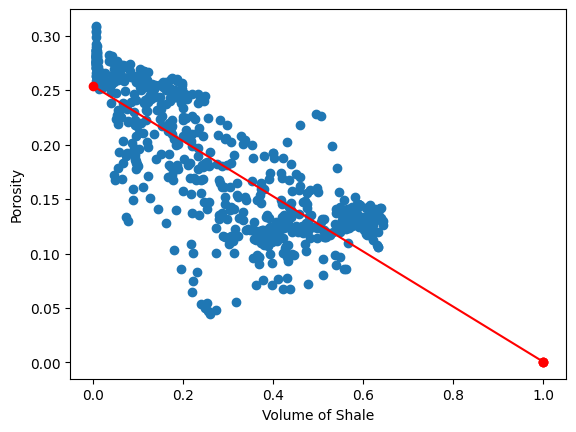

In [10]:
import numpy as np
fig = plt.figure()
plt.scatter(vcly_log, phit_log) #Scatter Vclay vs Porosity

#Fit a trend line
p = np.polyfit(vcly_log, phit_log,1)
vclay_endpoints = np.array([[0,1],[1,1]])
print(p)
plt.plot(vclay_endpoints, p[0]*vclay_endpoints + p[1],'-or')
plt.xlabel("Volume of Shale")
plt.ylabel("Porosity")


## Simulation of Elastic Properties
Another cool feature of `Rock`s in `rokpy` is the capability to simulate (calculate the elastic properties for a large number of reservoir properties) the rock elastic properties. This is done through the `simulate()` method of the `Rock` object. This methods receives reservoir properties (including porosity, volume fraction list and saturation list) and returning elastic properties (including P-wave velocity, S-wave velocity and density).
In following example, considering the statistical properties (mean and covariance) of available reservoir logs, we generate 1000 random samples of reservoir properties. We then simulate the elastic properties by these reservoir properties to study the statistical behaviour of the rock elastic properties.

Text(0.5, 0, 'Rho')

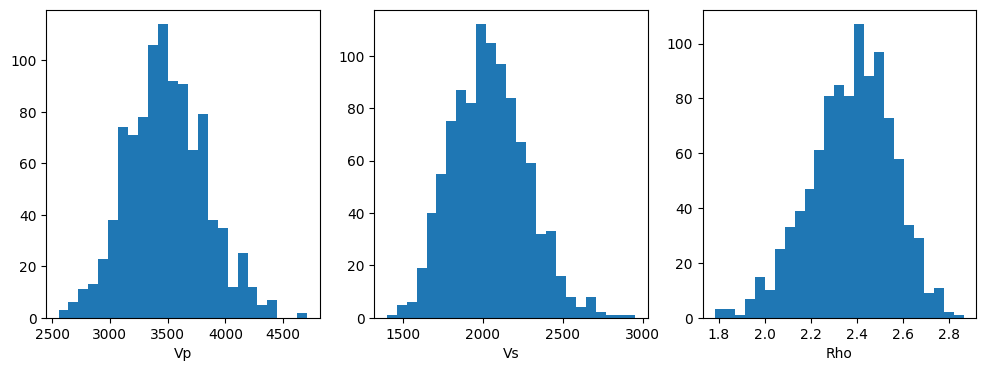

In [11]:
# Calculate the statistical parameters of reservoir properties
data = np.array([phit_log, vcly_log, sw_log])
cov = np.cov(data)
mean = np.mean(data, axis=1)

# Draw random samples from joint distribution of reservoir properties
samples = np.random.multivariate_normal(mean, cov, size=1000)
phi_samp = samples[:,0]
vcly_samp = samples[:,1]
sw_samp = samples[:,2]

# Filter out irrational samples
phi_samp[phi_samp<=0]=0.0001
vcly_samp[vcly_samp<=0]=0.0001
sw_samp[sw_samp<=0]=0.0001

# Simulate elastic properties
vp_samp, vs_samp, rho_samp = rock.simulate(phi_samp, [vcly_samp,1-vcly_samp], [sw_samp, 1-sw_samp])

# Display result
fig = plt.figure(figsize=(12,4))
plt1 = plt.subplot(131)
plt2 = plt.subplot(132)
plt3 = plt.subplot(133)
plt1.hist(vp_samp,25)
plt2.hist(vs_samp,25)
plt3.hist(rho_samp,25)
plt1.set_xlabel('Vp')
plt2.set_xlabel('Vs')
plt3.set_xlabel('Rho')

## Modeling by raw effective medium relations

We can also model rock elastic properties using the raw mathemetical relations in `effective_medium` module. In this section we implement the compare the results obtained from the `rock` model with those estimated from relations (methods). 

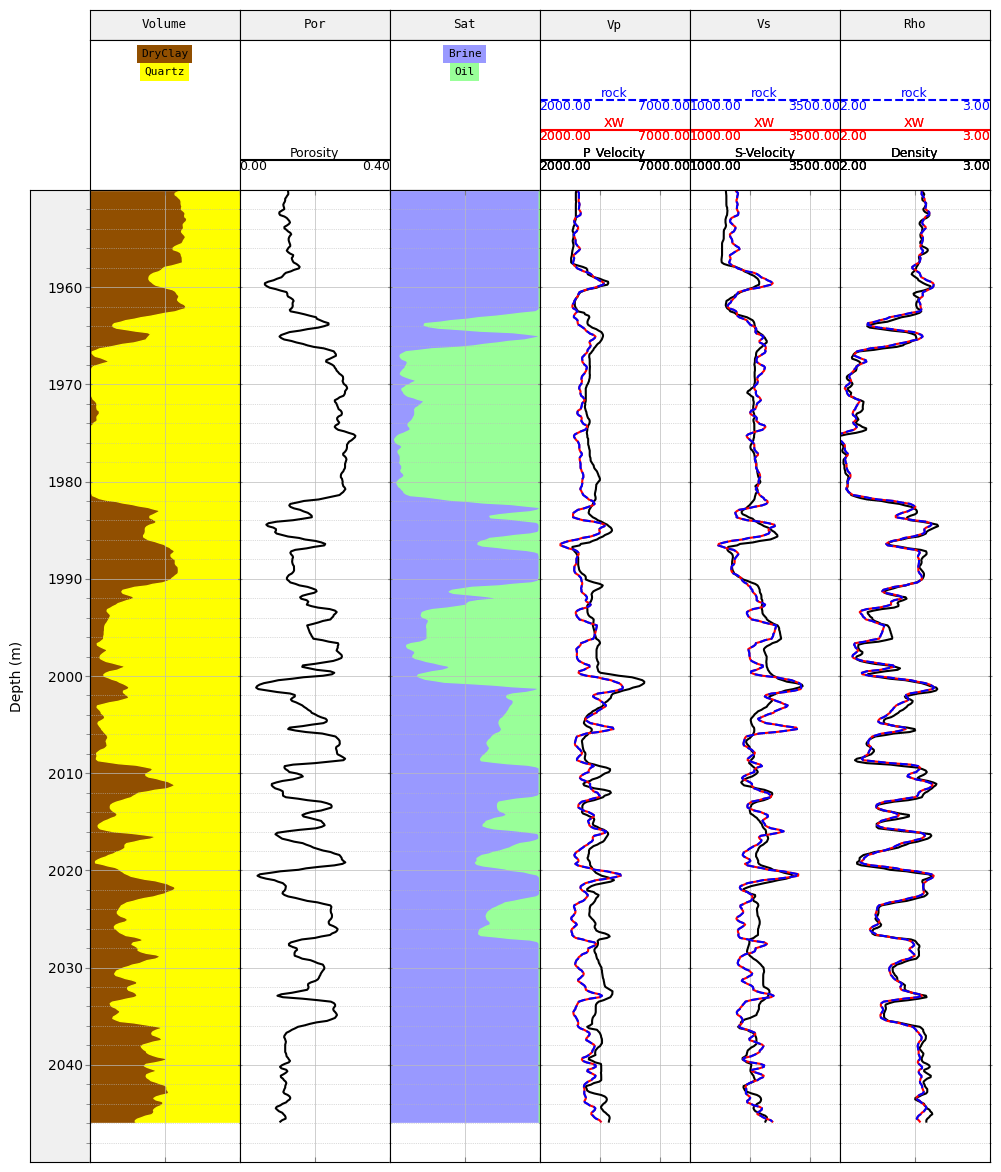

In [12]:
from rokpy.effective_medium import BoundMethods, InclusionMethods, FluidEffectMethods
from rokpy.conversions import modulus_to_velocity
import warnings
warnings.filterwarnings('ignore')

# Define Rock by InclusionRock class (3 lines of code!):
rock = InclusionRock( mineralset, fluidset, phit, InclusionMethods.InclusionMethodName.DEM)
rock.add_inclusion(clay_inclusion, clay)
rock.add_inclusion(quartz_inclusion, quartz)


# Define Rock (only elastic properties) by methods (many lines of code!):
Km, Gm = BoundMethods.voigt_reuss_hill([clay.bulk, quartz.bulk], [clay.shear, quartz.shear], [vcly_log, 1-vcly_log], upper_weight=0.5)
Kf, Gf = BoundMethods.voigt_reuss_hill([brine.bulk, oil.bulk], [brine.shear, oil.shear], [sw_log, 1-sw_log], upper_weight=0)
rhom = vcly_log*clay.density + (1 - vcly_log)*quartz.density
rhof = sw_log*brine.density + (1 - sw_log)*oil.density

phi_shale = vcly_log*phit_log
phi_sand = (1 - vcly_log)*phit_log
inclusion_set = {clay_inclusion: phi_shale, quartz_inclusion: phi_sand}

Kdry, Gdry = InclusionMethods.dem(Km, Gm, inclusion_set)
ksat, Gsat = FluidEffectMethods.gassmann(Kdry, Gdry, Km, Kf, phit_log)
rhob = rhom*(1 - phit_log) + rhof*phit_log
Vp, Vs = modulus_to_velocity(ksat, Gsat, rhob)


# Display results
vp_tr.plot(depth, rock.p_velocity, label='rock', color='blue', linestyle='dashed')
vs_tr.plot(depth, rock.s_velocity, label='rock', color='blue', linestyle='dashed')
ro_tr.plot(depth, rock.density, label='rock', color='blue', linestyle='dashed')
sheet
